Imports

In [23]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

Constants

dB/dt = µB(1-µ/K)

µ: growth rate without antibiotics = 0.057 h-1 


K: Carrying capacity of bacteria in the lungs: 2.3e8 CFU/ml


In [ ]:
u = 0.057 # h-1
K = 2.3e8 #CFU/ml
o = 10e3 #input of CFU/ml/h 
l = 0.1 #killing rate due to antibiotics
p = 0.1 # killing rate due to immune system

#o IS A PLACEHOLDER FOR MICROASPIRATION COEFFICIENT *  BACTERIAL DENSITY IN THE NASAL PHARYNX AT ONE TIME. 
#l and p are also PLACEHOLDERS

c = [u, K, o, l , p] # constants vector (recommended format by Prof. Kim)

NameError: name 'gamma' is not defined

Why does the following function need a t?
because it builds it at each time point for the values - each rate is dependent on the value of the function at the instantaneous moment before - hence being a differential equation. 

dBdt ODE

In [ ]:
def bacterial_growth(t, B, c): # calculates the rate of change (dBdt) at one time using the current bacterial population
    dBdt = c[0] * B * (1 - (B/c[1])) + c[2] - (c[3] * B) - (c[4] * B)
    return dBdt

tspan = np.linspace(0,300,100)
yinit = [5e5] #initial bacterial population at t = 0, CFU/ml
rtol = 1e-5 #don't change for now

sol = solve_ivp(lambda t, y: bacterial_growth(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)

Plotting the results

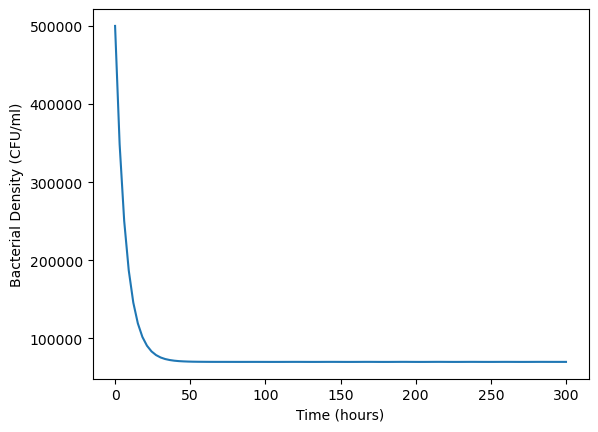

In [ ]:
plt.plot(sol.t, sol.y[0])
plt.ylabel("Bacterial Density (CFU/ml)")
plt.xlabel("Time (hours)")
plt.show()

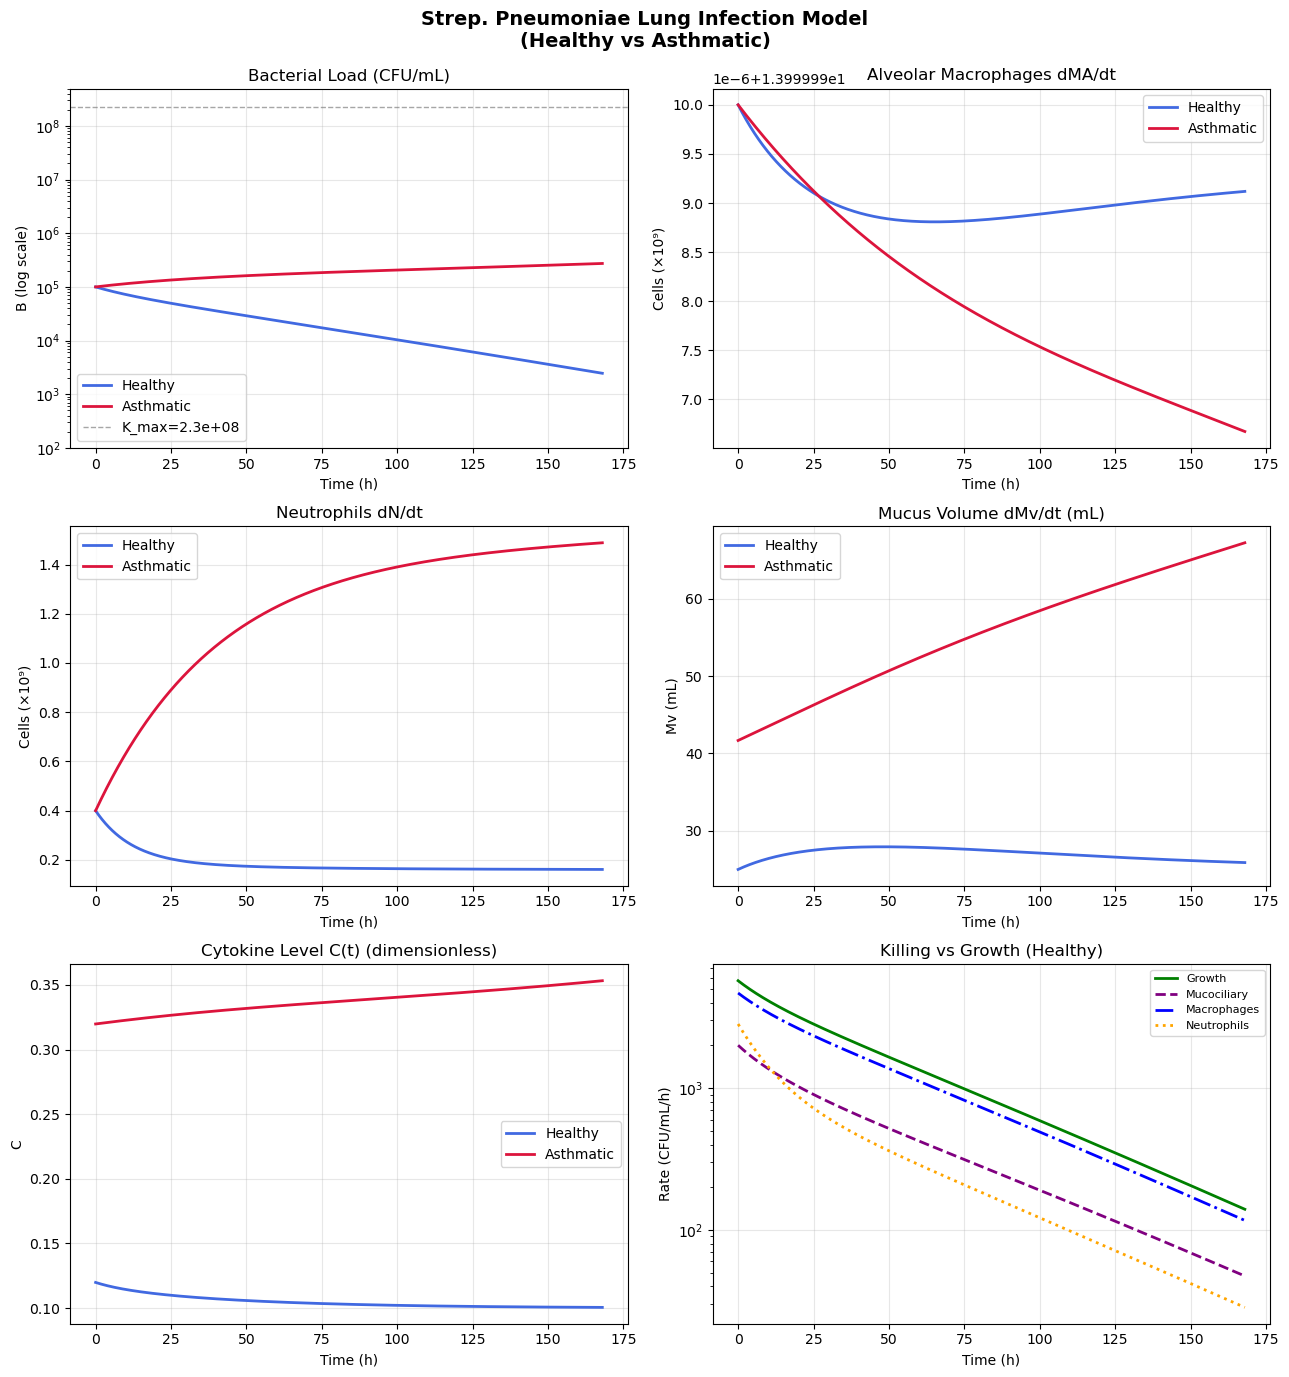